In [186]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [187]:
df = pd.DataFrame()

In [188]:
df['X1'] = [1,2,3,4,5,5,6,7,8,9]
df['X2'] = [9,8,8,6,5,4,3,9,5,7]
df['label'] = [1,0,1,0,1,1,1,1,0,0]

In [189]:
df

,X1,X2,label
0,1,9,1
1,2,8,0
2,3,8,1
3,4,6,0
4,5,5,1
5,5,4,1
6,6,3,1
7,7,9,1
8,8,5,0
9,9,7,0


In [190]:
import seaborn as sns

<Axes: xlabel='X1', ylabel='X2'>

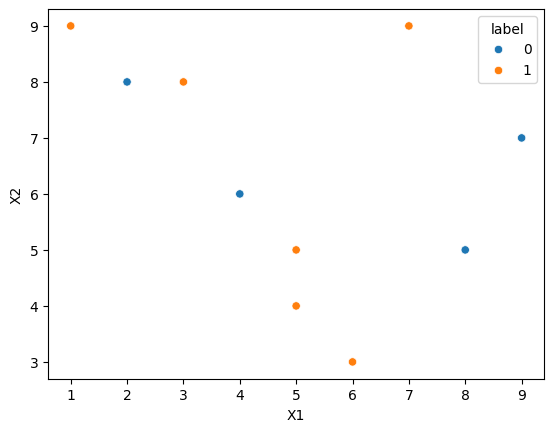

In [191]:
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [192]:
df['weights'] = 1/df.shape[0]  # assigning weights to each rows

In [193]:
df

,X1,X2,label,weights
0,1,9,1,0.1
1,2,8,0,0.1
2,3,8,1,0.1
3,4,6,0,0.1
4,5,5,1,0.1
5,5,4,1,0.1
6,6,3,1,0.1
7,7,9,1,0.1
8,8,5,0,0.1
9,9,7,0,0.1


In [194]:
## create Descision Stump
from sklearn.tree import DecisionTreeClassifier

In [195]:
dt = DecisionTreeClassifier(max_depth=1)

In [196]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [197]:
dt.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 7.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.625, 0.5, '  False')]

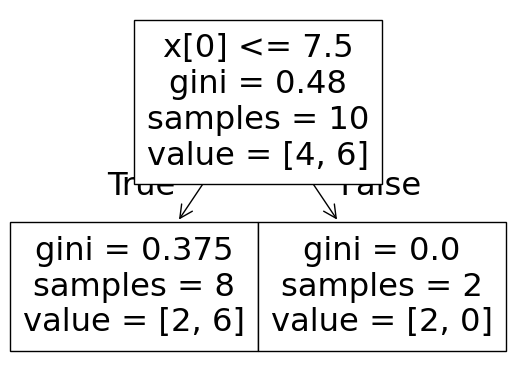

In [198]:
from sklearn.tree import plot_tree
plot_tree(dt)

<Axes: >

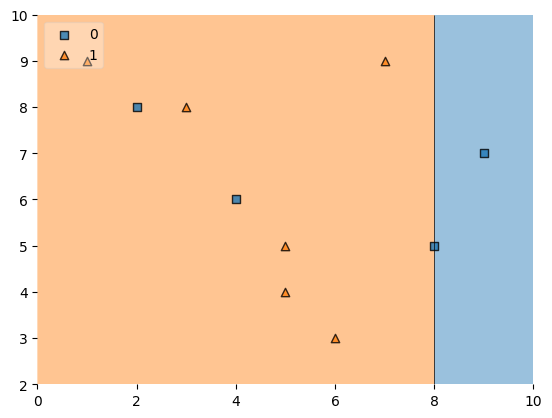

In [199]:
plot_decision_regions(X,y, clf=dt,legend=2)

In [200]:
df['y_pred'] = dt.predict(X)

In [201]:
df

,X1,X2,label,weights,y_pred
0,1,9,1,0.1,1
1,2,8,0,0.1,1
2,3,8,1,0.1,1
3,4,6,0,0.1,1
4,5,5,1,0.1,1
5,5,4,1,0.1,1
6,6,3,1,0.1,1
7,7,9,1,0.1,1
8,8,5,0,0.1,0
9,9,7,0,0.1,0


In [202]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error+0.0000000000001))

In [203]:
## step 3: Calculate model weight
alpha = calculate_model_weight(0.2)
alpha

np.float64(0.6931471805596953)

In [204]:
## step 4: Update weights
def update_row_weights(row, alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [205]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [206]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,9,1,0.1,1,0.065508
1,2,8,0,0.1,1,0.152653
2,3,8,1,0.1,1,0.065508
3,4,6,0,0.1,1,0.152653
4,5,5,1,0.1,1,0.065508
5,5,4,1,0.1,1,0.065508
6,6,3,1,0.1,1,0.065508
7,7,9,1,0.1,1,0.065508
8,8,5,0,0.1,0,0.065508
9,9,7,0,0.1,0,0.065508


In [207]:
df['updated_weights'].sum()

np.float64(0.8293697656827363)

In [208]:
df['normalised_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [209]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalised_weights
0,1,9,1,0.1,1,0.065508,0.078985
1,2,8,0,0.1,1,0.152653,0.184060
2,3,8,1,0.1,1,0.065508,0.078985
3,4,6,0,0.1,1,0.152653,0.184060
4,5,5,1,0.1,1,0.065508,0.078985
5,5,4,1,0.1,1,0.065508,0.078985
6,6,3,1,0.1,1,0.065508,0.078985
7,7,9,1,0.1,1,0.065508,0.078985
8,8,5,0,0.1,0,0.065508,0.078985
9,9,7,0,0.1,0,0.065508,0.078985


In [210]:
df['normalised_weights'].sum()

np.float64(1.0)

In [211]:
## Range
df['cumsum_upper'] = np.cumsum(df['normalised_weights'])
df['cumsum_lower'] = df.cumsum_upper - df['normalised_weights']

In [212]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalised_weights,cumsum_upper,cumsum_lower
0,1,9,1,0.1,1,0.065508,0.078985,0.078985,0.000000
1,2,8,0,0.1,1,0.152653,0.184060,0.263045,0.078985
2,3,8,1,0.1,1,0.065508,0.078985,0.342030,0.263045
3,4,6,0,0.1,1,0.152653,0.184060,0.526089,0.342030
4,5,5,1,0.1,1,0.065508,0.078985,0.605074,0.526089
5,5,4,1,0.1,1,0.065508,0.078985,0.684060,0.605074
6,6,3,1,0.1,1,0.065508,0.078985,0.763045,0.684060
7,7,9,1,0.1,1,0.065508,0.078985,0.842030,0.763045
8,8,5,0,0.1,0,0.065508,0.078985,0.921015,0.842030
9,9,7,0,0.1,0,0.065508,0.078985,1.000000,0.921015


In [213]:
## Upsampling
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [214]:
index_values = create_new_dataset(df)
index_values

[4, 0, 8, 5, 3, 8, 2, 1, 1, 4]

In [215]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [216]:
second_df

,X1,X2,label,weights
4,5,5,1,0.1
0,1,9,1,0.1
8,8,5,0,0.1
5,5,4,1,0.1
3,4,6,0,0.1
8,8,5,0,0.1
2,3,8,1,0.1
1,2,8,0,0.1
1,2,8,0,0.1
4,5,5,1,0.1


In [217]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [218]:
X2 = second_df.iloc[:,0:2].values
y2 = second_df.iloc[:,2].values

In [219]:
dt2.fit(X2,y2)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 6.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.625, 0.5, '  False')]

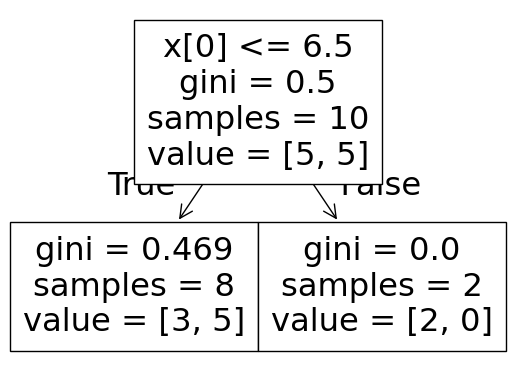

In [220]:
plot_tree(dt2)

<Axes: >

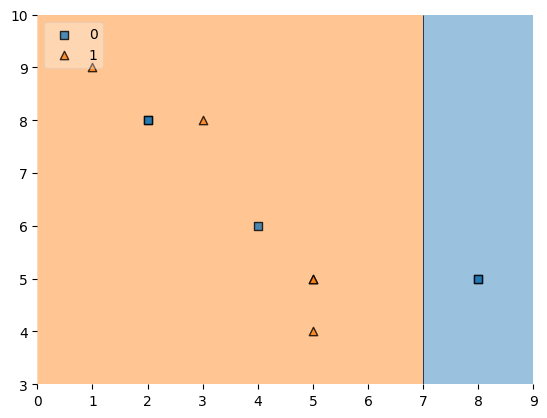

In [221]:
plot_decision_regions(X2,y2, clf=dt2,legend=2)

In [222]:
second_df['y_pred'] = dt2.predict(X)

In [223]:
second_df

,X1,X2,label,weights,y_pred
4,5,5,1,0.1,1
0,1,9,1,0.1,1
8,8,5,0,0.1,1
5,5,4,1,0.1,1
3,4,6,0,0.1,1
8,8,5,0,0.1,1
2,3,8,1,0.1,1
1,2,8,0,0.1,0
1,2,8,0,0.1,0
4,5,5,1,0.1,0


In [224]:
alpha2 = calculate_model_weight(0.5)

In [225]:
alpha2

np.float64(-1.0003109451873661e-13)

In [226]:
## step 4: Update weights
def update_row_weights(row, alpha=-1.0):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [227]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [228]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
4,5,5,1,0.1,1,0.271828
0,1,9,1,0.1,1,0.271828
8,8,5,0,0.1,1,0.036788
5,5,4,1,0.1,1,0.271828
3,4,6,0,0.1,1,0.036788
8,8,5,0,0.1,1,0.036788
2,3,8,1,0.1,1,0.271828
1,2,8,0,0.1,0,0.271828
1,2,8,0,0.1,0,0.271828
4,5,5,1,0.1,0,0.036788


In [229]:
second_df['normalised_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [230]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalised_weights
4,5,5,1,0.1,1,0.271828,0.152874
0,1,9,1,0.1,1,0.271828,0.152874
8,8,5,0,0.1,1,0.036788,0.020689
5,5,4,1,0.1,1,0.271828,0.152874
3,4,6,0,0.1,1,0.036788,0.020689
8,8,5,0,0.1,1,0.036788,0.020689
2,3,8,1,0.1,1,0.271828,0.152874
1,2,8,0,0.1,0,0.271828,0.152874
1,2,8,0,0.1,0,0.271828,0.152874
4,5,5,1,0.1,0,0.036788,0.020689


In [231]:
## Range
second_df['cumsum_upper'] = np.cumsum(second_df['normalised_weights'])
second_df['cumsum_lower'] = second_df.cumsum_upper - second_df['normalised_weights']

In [232]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalised_weights,cumsum_upper,cumsum_lower
4,5,5,1,0.1,1,0.271828,0.152874,0.152874,0.000000
0,1,9,1,0.1,1,0.271828,0.152874,0.305748,0.152874
8,8,5,0,0.1,1,0.036788,0.020689,0.326437,0.305748
5,5,4,1,0.1,1,0.271828,0.152874,0.479311,0.326437
3,4,6,0,0.1,1,0.036788,0.020689,0.500000,0.479311
8,8,5,0,0.1,1,0.036788,0.020689,0.520689,0.500000
2,3,8,1,0.1,1,0.271828,0.152874,0.673563,0.520689
1,2,8,0,0.1,0,0.271828,0.152874,0.826437,0.673563
1,2,8,0,0.1,0,0.271828,0.152874,0.979311,0.826437
4,5,5,1,0.1,0,0.036788,0.020689,1.000000,0.979311


In [233]:
## Upsampling
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [234]:
index_values = create_new_dataset(second_df)
index_values

[1, 8, 5, 1, 4, 1, 1, 4, 4, 0]

In [235]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [236]:
third_df

,X1,X2,label,weights
0,1,9,1,0.1
1,2,8,0,0.1
8,8,5,0,0.1
0,1,9,1,0.1
3,4,6,0,0.1
0,1,9,1,0.1
0,1,9,1,0.1
3,4,6,0,0.1
3,4,6,0,0.1
4,5,5,1,0.1


In [237]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

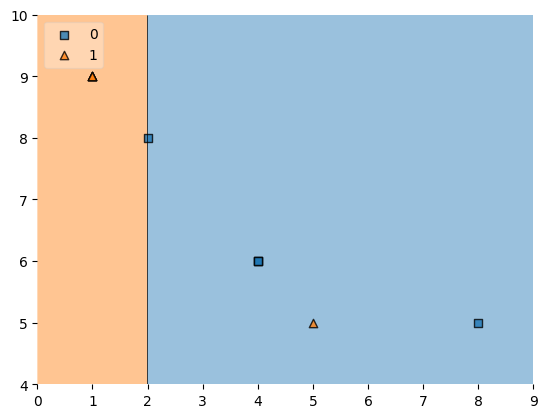

In [238]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [239]:
third_df['y_pred'] = dt3.predict(X)

In [240]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936731)

In [242]:
print(alpha,alpha2,alpha3)

0.6931471805596953 -1.0003109451873661e-13 -0.4236489301936731


In [243]:
## Prediction  - 1,9 = 1

In [245]:
query = np.array([1,9]).reshape(1,2)
dt.predict(query)

array([1])

In [246]:
dt2.predict(query)

array([1])

In [247]:
dt3.predict(query)

array([1])

In [248]:
alpha*(1) + alpha2*(1) + alpha3*(1)

np.float64(0.2694982503659221)

In [249]:
np.sign(0.2694)

np.float64(1.0)

In [ ]:
# 2	8	o/p=0

In [251]:
query1 = np.array([2,8]).reshape(1,2)
dt.predict(query1)

array([1])

In [252]:
dt2.predict(query1)

array([1])

In [253]:
dt3.predict(query1)

array([0])

In [255]:
alpha*(1) + alpha2*(1) + alpha3*(0)

np.float64(0.6931471805595952)

In [256]:
np.sign(0.6931471)

np.float64(1.0)